In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

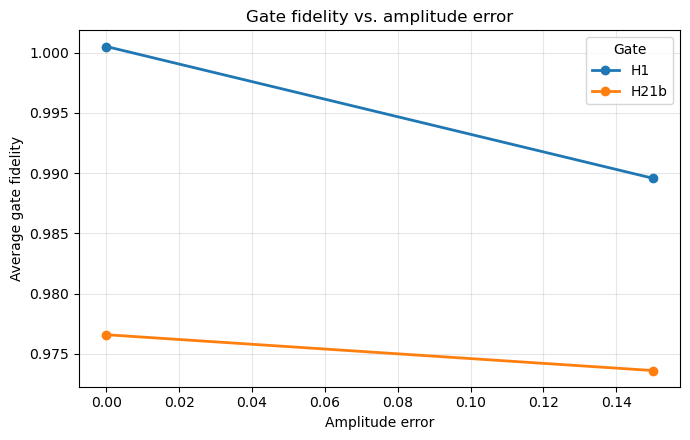

In [9]:
data_path = Path("/home/petar/qti/universal-half-pi/results/run_2000_shot_H21b_QB19_qubits_2_rabi/composite_tomography_results.csv")
results = pd.read_csv(data_path)

fidelity_by_detuning = (
    results[results["sequence"].isin(["H1", "H21b"])]
    .groupby(["sequence", "amplitude_error"], as_index=False)["average_gate_fidelity"]
    .mean()
)

fig, ax = plt.subplots(figsize=(7, 4.5))
for sequence in ["H1", "H21b"]:
    gate_data = fidelity_by_detuning.query("sequence == @sequence").sort_values("amplitude_error")
    ax.plot(
        gate_data["amplitude_error"],
        gate_data["average_gate_fidelity"],
        marker="o",
        linewidth=2,
        label=sequence,
    )

ax.set_xlabel("Amplitude error")
ax.set_ylabel("Average gate fidelity")
ax.set_title("Gate fidelity vs. amplitude error")
ax.grid(alpha=0.3)
ax.legend(title="Gate")
fig.tight_layout()
plt.show()

In [10]:
fidelity_by_detuning

,sequence,amplitude_error,average_gate_fidelity
0,H1,0.00,1.000521
1,H1,0.15,0.989582
2,H21b,0.00,0.976581
3,H21b,0.15,0.973607
